# HW5 Lab: Named Entity Recognition (NER) 🏷️

<!-- lab-header:begin -->
**MIS 769 · Big Data Analytics for Business · Fall 2026**

**Points:** 40  |  **Due:** Sunday, October 4, 2026 at 10:00 PM Pacific

**Dr. Richard J. Young** · UNLV Lee Business School
<!-- lab-header:end -->

> **Why are we learning this?** Reviews, tickets, and news mention companies, products,
> people, places, and prices by name — and those names are the analyzable facts buried in
> free text. NER turns "I bought a Kindle at the Las Vegas Best Buy for $89" into
> structured data you can count, chart, and act on. The transferable skill:
> **turning unstructured text into a structured, queryable dataset** — the foundation of
> competitor monitoring, brand tracking, and compliance screening.

**How this lab works:** every cell below runs as-is — Runtime → Run all extracts and
charts entities from 5,000 real reviews. Your job: understand it, twist the knobs in the
🧪 Experiment cells, then point the pipeline at text from **a domain you're passionate
about** in the 🎮 Playground — where you'll catch spaCy missing YOUR world's jargon.

**The pipeline:** Raw reviews → spaCy NER → entity lists → frequency analysis → one chart a VP can read


## Learning objectives

- Explain what NER does and what spaCy's entity labels (ORG, GPE, PRODUCT…) mean
- Extract five business-relevant entity types from thousands of real reviews
- Analyze entity frequencies to answer "who/what/where do customers talk about?"
- Present entity patterns as a clean multi-panel visualization


## Part 1: Setup and Data (6 pts)

spaCy's English model is a separate download (a shell command, not a pip package name).
We load **5,000 Yelp reviews** — bounded on purpose: NER reads every word, so runtime
scales linearly with corpus size, and 5,000 keeps this under a few minutes on free Colab.


In [1]:
!pip install -q spacy datasets pandas matplotlib seaborn
!python -m spacy download en_core_web_sm -q

import spacy
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

nlp = spacy.load("en_core_web_sm")
print(f"✅ spaCy {spacy.__version__} | model: en_core_web_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 80.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ spaCy 3.8.16 | model: en_core_web_sm


In [2]:
from datasets import load_dataset

dataset = load_dataset("Yelp/yelp_review_full", split="train[:5000]")
df = dataset.to_pandas()
print(f"✅ Loaded {len(df):,} reviews")
print("Columns:", list(df.columns))   # 'label' = 0-4 stars, 'text' = the review
print("\nSample:", df["text"].iloc[0][:200], "...")

README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  299MB            

yelp_review_full/train-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

yelp_review_full/test-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 23.5MB            

yelp_review_full/test-00000-of-00001.par(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✅ Loaded 5,000 reviews
Columns: ['label', 'text']

Sample: dr. goldberg offers everything i look for in a general practitioner.  he's nice and easy to talk to without being patronizing; he's always on time in seeing his patients; he's affiliated with a top-no ...


## Part 2: NER Demo (8 pts)

Before running NER on 5,000 documents, understand what it produces on ONE. spaCy tags
spans of text with entity types:

| Entity | Meaning | Example |
|--------|---------|---------|
| PERSON | People | "Tim Cook" |
| ORG | Companies, agencies | "Apple", "IRS" |
| GPE | Countries, cities, states | "Las Vegas" |
| PRODUCT | Objects, vehicles, devices | "iPhone" |
| MONEY | Monetary values | "$89" |
| DATE / TIME | When | "last Tuesday", "3pm" |

Run the demo, **read every row of the output**, and note where the model is right, wrong,
or debatable — that skepticism is Q1.


In [3]:
sample_text = (
    "Apple CEO Tim Cook announced the new iPhone in San Francisco. "
    "The device costs $999 at Best Buy and Amazon. "
    "My waiter Carlos at the Bellagio in Las Vegas recommended it too."
)

doc = nlp(sample_text)
print("Named entities found:")
print("-" * 60)
for ent in doc.ents:
    print(f"{ent.text:20} | {ent.label_:8} | {spacy.explain(ent.label_)}")

Named entities found:
------------------------------------------------------------
Apple                | ORG      | Companies, agencies, institutions, etc.
Tim Cook             | PERSON   | People, including fictional
San Francisco        | GPE      | Countries, cities, states
999                  | MONEY    | Monetary values, including unit
Best Buy             | ORG      | Companies, agencies, institutions, etc.
Amazon               | ORG      | Companies, agencies, institutions, etc.
Carlos               | PERSON   | People, including fictional
Bellagio             | LOC      | Non-GPE locations, mountain ranges, bodies of water
Las Vegas            | GPE      | Countries, cities, states


In [4]:
# Same result, rendered visually (great for screenshots and slide decks)
from spacy import displacy
displacy.render(doc, style="ent", jupyter=True)

### 🧪 Experiment

- Rewrite `sample_text` to mention YOUR employer, your city, and a product you actually use. Does spaCy catch them all? Misses on niche brands here foreshadow what you'll see at scale.
- Lowercase the whole thing: `nlp(sample_text.lower())`. How many entities survive? (Capitalization is a huge NER clue — now think about all-lowercase tweets and chat logs.)
- Add a trap sentence: "I ordered the Big Mac and a Coke Zero at the McDonald's on Paradise Road." Which of those does the model tag, and with which labels — any debatable calls?


In [5]:
# experiment 1

sample_text = (
    "Credit One Bank CEO Robert DeJong announced hybrid work for the Las Vegas HQ teams."
    "The teams will be given a tech stipend to use at Amazon, Bestbuy or Apple. "
    "My home office chair by Hinomi is the best office chair I have ever had!"
)

doc = nlp(sample_text)
print("Named entities found:")
print("-" * 60)
for ent in doc.ents:
    print(f"{ent.text:20} | {ent.label_:8} | {spacy.explain(ent.label_)}")

Named entities found:
------------------------------------------------------------
Credit One Bank      | ORG      | Companies, agencies, institutions, etc.
Robert DeJong        | PERSON   | People, including fictional
the Las Vegas        | LOC      | Non-GPE locations, mountain ranges, bodies of water
Amazon               | ORG      | Companies, agencies, institutions, etc.
Apple                | ORG      | Companies, agencies, institutions, etc.
Hinomi               | PERSON   | People, including fictional


# experiment 1 analysis
Words that sound like names instead of brands are difficult to properly catch. Hinomi is a name in Japanese but it is also a brand of an office furniture company.

In [6]:
# experiment 2: lowercase test

doc_lower = nlp(sample_text.lower())

print("Named entities found (lowercased text):")
print("-" * 60)
for ent in doc_lower.ents:
    print(f"{ent.text:20} | {ent.label_:8} | {spacy.explain(ent.label_)}")

print(f"\nOriginal: {len(nlp(sample_text).ents)} entities | Lowercased: {len(doc_lower.ents)} entities")

Named entities found (lowercased text):
------------------------------------------------------------
one                  | CARDINAL | Numerals that do not fall under another type
robert dejong        | PERSON   | People, including fictional
las vegas            | GPE      | Countries, cities, states

Original: 6 entities | Lowercased: 3 entities


# experiment 2 analysis
Only half the entities survive. If there is a lot more slang, or poor neighboring clues enity identification likely would degrade.

In [7]:
# experiment 3

sample_text = (
    "Credit One Bank CEO Robert DeJong announced hybrid work for the Las Vegas HQ teams."
    "The teams will be given a tech stipend to use at Amazon, Bestbuy or Apple. "
    "My home office chair by Hinomi is the best office chair I have ever had!"
    "I ordered the Big Mac and a Coke Zero at the McDonald's on Paradise Road."
)

doc = nlp(sample_text)
print("Named entities found:")
print("-" * 60)
for ent in doc.ents:
    print(f"{ent.text:20} | {ent.label_:8} | {spacy.explain(ent.label_)}")

Named entities found:
------------------------------------------------------------
Credit One Bank      | ORG      | Companies, agencies, institutions, etc.
Robert DeJong        | PERSON   | People, including fictional
the Las Vegas        | LOC      | Non-GPE locations, mountain ranges, bodies of water
Amazon               | ORG      | Companies, agencies, institutions, etc.
Apple                | ORG      | Companies, agencies, institutions, etc.
Hinomi               | PERSON   | People, including fictional
the Big Mac          | ORG      | Companies, agencies, institutions, etc.
McDonald             | ORG      | Companies, agencies, institutions, etc.
Paradise Road        | LOC      | Non-GPE locations, mountain ranges, bodies of water


# experiment 3 analysis
McDonald did get tagged along with Paradise road. Big Mac should not have been tagged as that is more of a product really.

## Part 3: Entity Extraction (12 pts)

Now scale it: run every review through spaCy and collect five entity types. This is the
highest-weighted part because it's the actual engineering — one function, applied
consistently, turning 5,000 blobs of prose into five clean lists.

Performance tip: `nlp.pipe(texts)` batches documents through the model and is much
faster than calling `nlp(text)` in a Python loop.


In [8]:
def extract_entities(doc):
    """Collect the five business-relevant entity types from one spaCy doc."""
    entities = {"ORG": [], "PRODUCT": [], "GPE": [], "PERSON": [], "MONEY": []}
    for ent in doc.ents:
        if ent.label_ in entities:
            entities[ent.label_].append(ent.text.strip())
    return entities

all_orgs, all_products, all_locations, all_persons, all_money = [], [], [], [], []

texts = [t[:1000] for t in df["text"]]          # truncate: keeps runtime predictable
print(f"Extracting entities from {len(texts):,} reviews (2-4 minutes on CPU)...")

for doc in nlp.pipe(texts, batch_size=64):
    ents = extract_entities(doc)
    all_orgs.extend(ents["ORG"])
    all_products.extend(ents["PRODUCT"])
    all_locations.extend(ents["GPE"])
    all_persons.extend(ents["PERSON"])
    all_money.extend(ents["MONEY"])

print(f"\n✅ ORG: {len(all_orgs):,} | PRODUCT: {len(all_products):,} | "
      f"GPE: {len(all_locations):,} | PERSON: {len(all_persons):,} | MONEY: {len(all_money):,}")

Extracting entities from 5,000 reviews (2-4 minutes on CPU)...

✅ ORG: 3,357 | PRODUCT: 185 | GPE: 2,388 | PERSON: 3,364 | MONEY: 959


### 🧪 Experiment

- Add `"DATE": []` and `"TIME": []` to the dict in `extract_entities` (plus matching master lists) and re-run. Are temporal mentions more or less common than orgs in reviews — and what business question would they answer?
- Change the truncation from `t[:1000]` to `t[:300]` and re-run. How many entities do you lose, and how much time do you save? That's the speed/coverage trade-off every production pipeline prices out.
- Time it: wrap the loop with `import time; t0=time.time()` ... `print(time.time()-t0)`, then try `batch_size=8` vs `batch_size=256`. Does batching matter as much as the tip claims?


In [9]:
# experiment 1

def extract_entities_dt(doc):
    """Same as extract_entities, plus DATE and TIME."""
    entities = {"ORG": [], "PRODUCT": [], "GPE": [], "PERSON": [], "MONEY": [],
                "DATE": [], "TIME": []}
    for ent in doc.ents:
        if ent.label_ in entities:
            entities[ent.label_].append(ent.text.strip())
    return entities

all_dates, all_times = [], []

for doc in nlp.pipe(texts, batch_size=64):
    ents = extract_entities_dt(doc)
    all_dates.extend(ents["DATE"])
    all_times.extend(ents["TIME"])

print(f"ORG: {len(all_orgs):,} | DATE: {len(all_dates):,} | TIME: {len(all_times):,}")
print("\nTop 10 DATE mentions:", Counter(all_dates).most_common(10))
print("Top 10 TIME mentions:", Counter(all_times).most_common(10))

ORG: 3,357 | DATE: 2,651 | TIME: 1,930

Top 10 DATE mentions: [('Saturday', 105), ('today', 94), ('Friday', 85), ('the day', 79), ('Sunday', 77), ('years', 57), ('yesterday', 38), ('the years', 34), ('Thursday', 32), ('daily', 28)]
Top 10 TIME mentions: [('night', 100), ('afternoon', 66), ('last night', 63), ('evening', 52), ('tonight', 43), ('Saturday night', 41), ('morning', 39), ('an hour', 34), ('10 minutes', 33), ('20 minutes', 31)]


In [10]:
# experiment 2

import time

def run_ner(text_list, batch_size=64):
    """Run NER over text_list; return (total entities in the 5 types, seconds)."""
    t0 = time.time()
    total = 0
    for doc in nlp.pipe(text_list, batch_size=batch_size):
        ents = extract_entities(doc)
        total += sum(len(v) for v in ents.values())
    return total, time.time() - t0

texts_1000 = [t[:1000] for t in df["text"]]
texts_300 = [t[:300] for t in df["text"]]

n_1000, sec_1000 = run_ner(texts_1000)
n_300, sec_300 = run_ner(texts_300)

print(f"t[:1000] -> {n_1000:,} entities in {sec_1000:.1f}s")
print(f"t[:300]  -> {n_300:,} entities in {sec_300:.1f}s")
print(f"\nEntities lost: {n_1000 - n_300:,} ({(n_1000 - n_300) / n_1000:.1%})")
print(f"Time saved:    {sec_1000 - sec_300:.1f}s ({(sec_1000 - sec_300) / sec_1000:.1%})")

t[:1000] -> 10,253 entities in 77.0s
t[:300]  -> 5,528 entities in 37.4s

Entities lost: 4,725 (46.1%)
Time saved:    39.6s (51.4%)


In [11]:
# experiment 3

import time

subset = texts[:2000]

for bs in [8, 64, 256]:
    t0 = time.time()
    for doc in nlp.pipe(subset, batch_size=bs):
        pass
    print(f"batch_size={bs:>3} -> {time.time() - t0:.1f}s")

batch_size=  8 -> 40.1s
batch_size= 64 -> 31.1s
batch_size=256 -> 30.2s


## Part 4: Analyze Patterns (8 pts)

Raw lists become insight when you count them. "Which organizations come up most in
customer conversations?" is a question a brand manager pays for — and you can now answer
it with three lines of `Counter`:


In [12]:
org_counts = Counter(all_orgs).most_common(15)
location_counts = Counter(all_locations).most_common(10)
person_counts = Counter(all_persons).most_common(10)

for title, counts in [("TOP 15 ORGANIZATIONS", org_counts),
                      ("TOP 10 LOCATIONS", location_counts),
                      ("TOP 10 PEOPLE", person_counts)]:
    print(f"\n📊 {title}")
    print("-" * 40)
    for name, count in counts:
        print(f"   {name:30} {count:4}")


📊 TOP 15 ORGANIZATIONS
----------------------------------------
   Lidia                            57
   Whole Foods                      46
   Yelp                             35
   Tessaro                          35
   Westin                           29
   BBQ                              26
   Starbucks                        25
   ATM                              23
   BYOB                             20
   Shadyside                        20
   Big Burrito                      18
   Beto                             18
   Penn Mac                         18
   GE                               17
   Primanti                         17

📊 TOP 10 LOCATIONS
----------------------------------------
   Pittsburgh                      852
   Shadyside                        48
   Bloomfield                       44
   Casbah                           41
   Chicago                          33
   pittsburgh                       32
   the Strip District               20
   Oakland      

### 🧪 Experiment

- Count `Counter(all_money).most_common(15)` — what price points dominate customer conversations, and is that itself a finding?
- Merge case variants: rebuild `org_counts` from `Counter(o.lower() for o in all_orgs)`. How much do counts change when 'Subway' and 'subway' unify — and what NEW error does lowercasing introduce?
- Look for a split entity: is 'Vegas' counted separately from 'Las Vegas' in `location_counts`? Write the two-line fix (map one onto the other before counting) and re-count.


**Pause and look (feeds Q1 and Q4):** scan those lists critically. Is a restaurant name
showing up under PERSON? Is "Vegas" split from "Las Vegas"? NER output is *useful*, not
*perfect* — the errors you spot here are exactly what you'd budget cleanup time for in a
real project.


In [13]:
# experiment 1

money_counts = Counter(all_money).most_common(15)

print("\n💰 TOP 15 MONEY MENTIONS")
print("-" * 40)
for amount, count in money_counts:
    print(f"   {amount:30} {count:4}")


💰 TOP 15 MONEY MENTIONS
----------------------------------------
   10                               49
   5                                36
   1                                31
   20                               31
   2                                28
   12                               23
   15                               22
   30                               19
   7                                19
   50                               15
   25                               15
   3                                14
   2.50                             13
   8                                12
   4                                12


In [14]:
# experiment 2

org_counts_lower = Counter(o.lower() for o in all_orgs).most_common(15)

print(f"{'ORIGINAL CASE':32}{'LOWERCASED (merged)':32}")
print("-" * 64)
for (o1, c1), (o2, c2) in zip(org_counts, org_counts_lower):
    print(f"{o1:25}{c1:5}   {o2:25}{c2:5}")

# NEW error check: which lowercased names merged more than one original spelling?
from collections import defaultdict
variants = defaultdict(set)
for o in all_orgs:
    variants[o.lower()].add(o)

print("\nNames that collapsed multiple spellings into one:")
for name, spellings in sorted(variants.items(), key=lambda kv: -len(kv[1]))[:10]:
    if len(spellings) > 1:
        print(f"   {name!r:25} <- {sorted(spellings)}")

ORIGINAL CASE                   LOWERCASED (merged)             
----------------------------------------------------------------
Lidia                       57   lidia                       57
Whole Foods                 46   whole foods                 46
Yelp                        35   yelp                        35
Tessaro                     35   tessaro                     35
Westin                      29   westin                      30
BBQ                         26   bbq                         26
Starbucks                   25   starbucks                   25
ATM                         23   atm                         23
BYOB                        20   shadyside                   22
Shadyside                   20   ge                          21
Big Burrito                 18   byob                        21
Beto                        18   big burrito                 18
Penn Mac                    18   beto                        18
GE                          17   penn 

In [15]:
# experiment 3

print("Current Vegas-related entries:")
for loc, count in Counter(all_locations).most_common():
    if "vegas" in loc.lower():
        print(f"   {loc:20} {count:4}")

# two-line fix: map the variants onto one name, then re-count
fixed_locations = ["Las Vegas" if loc.lower().removeprefix("the ") in ("vegas", "las vegas") else loc
                   for loc in all_locations]
location_counts_fixed = Counter(fixed_locations).most_common(10)

print("\n📊 TOP 10 LOCATIONS (after merge)")
print("-" * 40)
for name, count in location_counts_fixed:
    print(f"   {name:30} {count:4}")

Current Vegas-related entries:
   Las Vegas               1

📊 TOP 10 LOCATIONS (after merge)
----------------------------------------
   Pittsburgh                      852
   Shadyside                        48
   Bloomfield                       44
   Casbah                           41
   Chicago                          33
   pittsburgh                       32
   the Strip District               20
   Oakland                          20
   Dormont                          18
   Boston                           18


## Part 5: Visualization (6 pts)

One figure, three horizontal bar panels: organizations, locations, people. Horizontal
bars because entity names are long — never make a stakeholder read sideways.


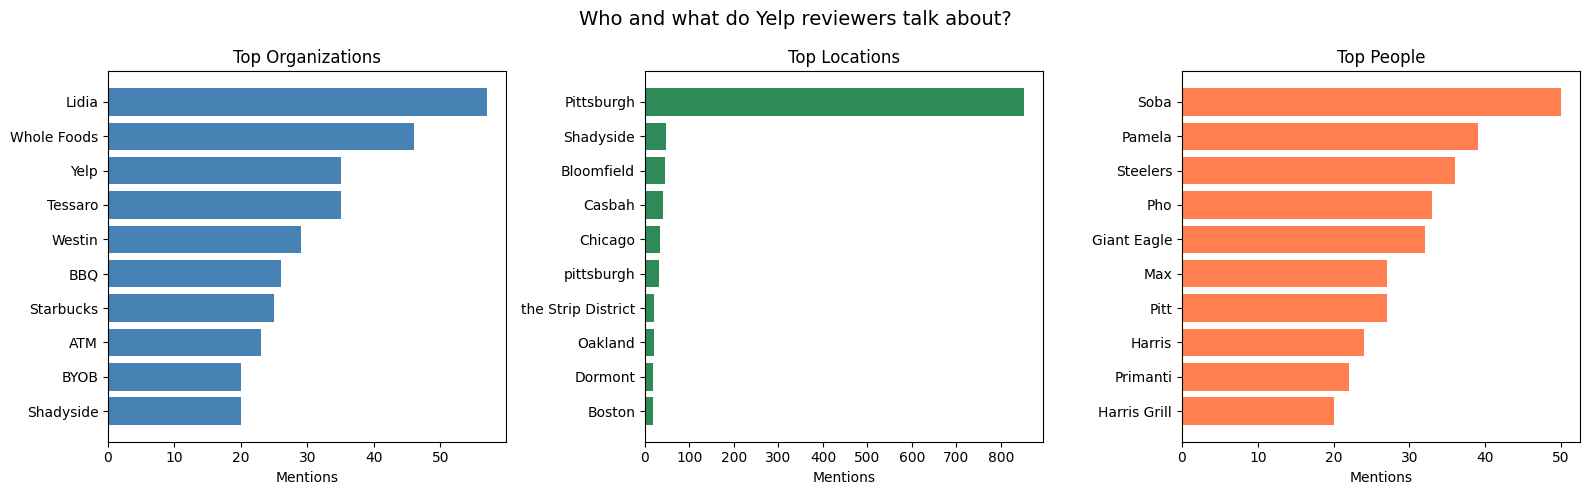

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
panels = [("Top Organizations", org_counts[:10], "steelblue"),
          ("Top Locations", location_counts[:10], "seagreen"),
          ("Top People", person_counts[:10], "coral")]

for ax, (title, counts, color) in zip(axes, panels):
    if counts:
        names, values = zip(*counts)
        ax.barh(names, values, color=color)
        ax.invert_yaxis()                      # most frequent on top
    ax.set_title(title)
    ax.set_xlabel("Mentions")

fig.suptitle("Who and what do Yelp reviewers talk about?", fontsize=14)
plt.tight_layout()
plt.show()

### 🧪 Experiment

- Swap the People panel for a Money panel built from `Counter(all_money).most_common(10)`. Which figure tells a brand manager more?
- Comment out `ax.invert_yaxis()` and re-run. Why does the chart suddenly feel wrong? (Small craft details like this are what make a chart executive-ready.)
- Show top 20 instead of top 10 in each panel. At what point does the chart stop being readable — and what does that imply for dashboards?


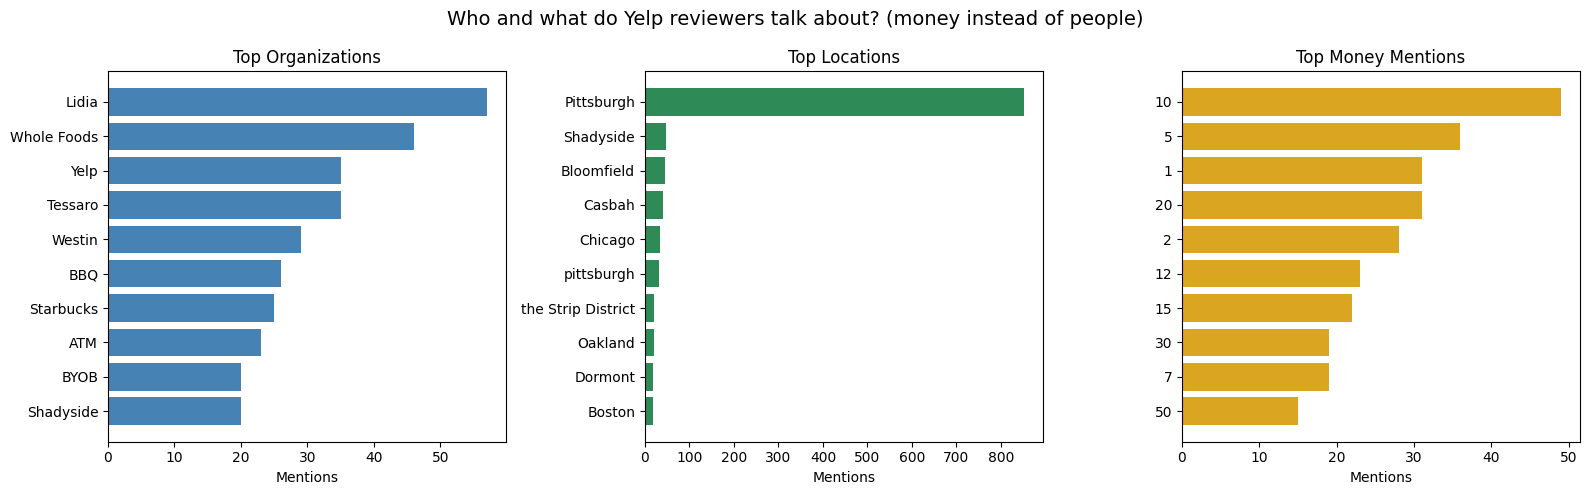

In [17]:
# experiment 1

money_counts10 = Counter(all_money).most_common(10)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
panels = [("Top Organizations", org_counts[:10], "steelblue"),
          ("Top Locations", location_counts[:10], "seagreen"),
          ("Top Money Mentions", money_counts10, "goldenrod")]

for ax, (title, counts, color) in zip(axes, panels):
    if counts:
        names, values = zip(*counts)
        ax.barh(names, values, color=color)
        ax.invert_yaxis()                      # most frequent on top
    ax.set_title(title)
    ax.set_xlabel("Mentions")

fig.suptitle("Who and what do Yelp reviewers talk about? (money instead of people)", fontsize=14)
plt.tight_layout()
plt.show()

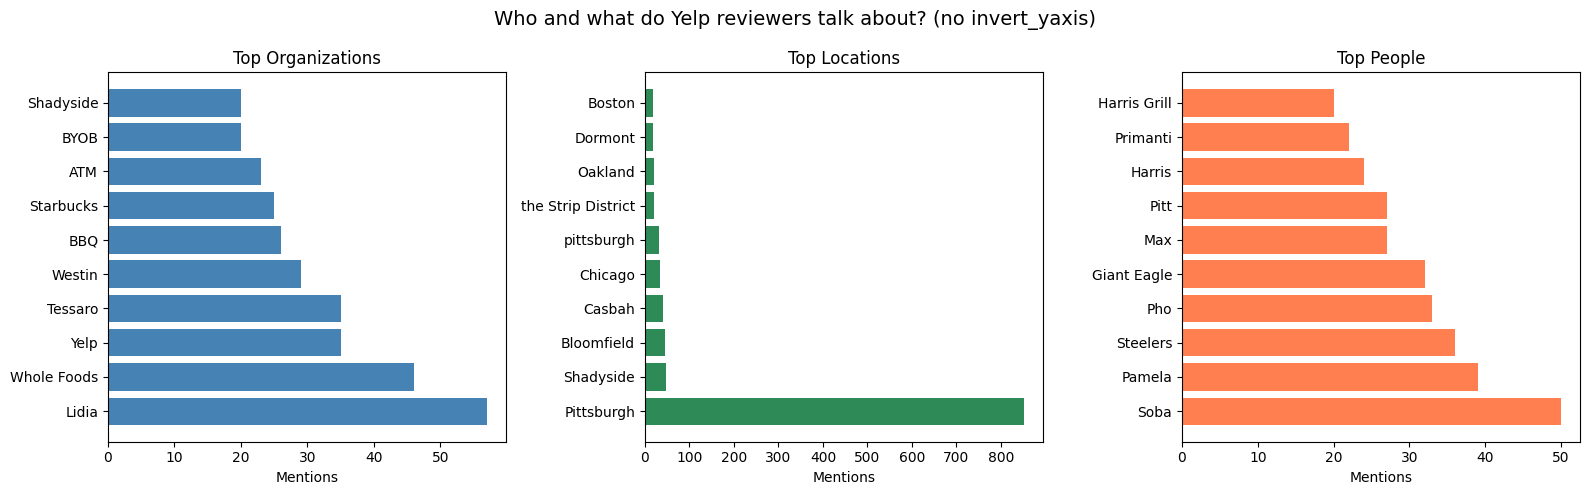

In [18]:
# experiment 2
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
panels = [("Top Organizations", org_counts[:10], "steelblue"),
          ("Top Locations", location_counts[:10], "seagreen"),
          ("Top People", person_counts[:10], "coral")]

for ax, (title, counts, color) in zip(axes, panels):
    if counts:
        names, values = zip(*counts)
        ax.barh(names, values, color=color)
        # ax.invert_yaxis()                    # <- commented out for this experiment
    ax.set_title(title)
    ax.set_xlabel("Mentions")

fig.suptitle("Who and what do Yelp reviewers talk about? (no invert_yaxis)", fontsize=14)
plt.tight_layout()
plt.show()

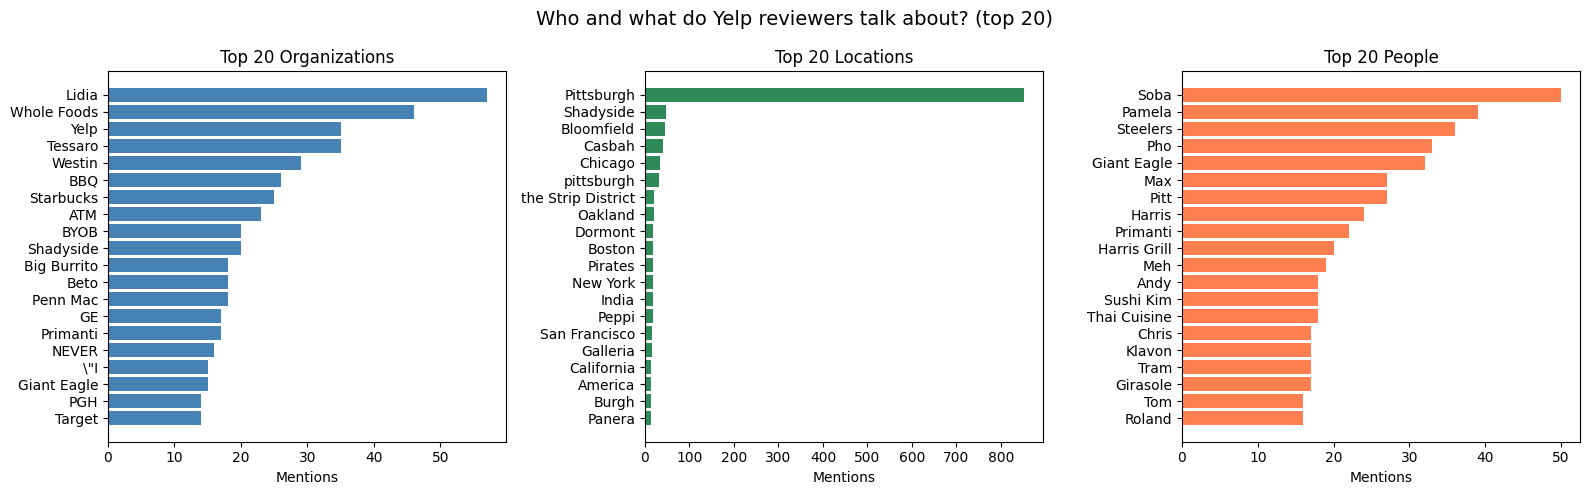

In [19]:
# experiment 3
org_counts20 = Counter(all_orgs).most_common(20)
location_counts20 = Counter(all_locations).most_common(20)
person_counts20 = Counter(all_persons).most_common(20)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))        # same figsize on purpose: watch readability
panels = [("Top 20 Organizations", org_counts20, "steelblue"),
          ("Top 20 Locations", location_counts20, "seagreen"),
          ("Top 20 People", person_counts20, "coral")]

for ax, (title, counts, color) in zip(axes, panels):
    if counts:
        names, values = zip(*counts)
        ax.barh(names, values, color=color)
        ax.invert_yaxis()                      # most frequent on top
    ax.set_title(title)
    ax.set_xlabel("Mentions")

fig.suptitle("Who and what do Yelp reviewers talk about? (top 20)", fontsize=14)
plt.tight_layout()
plt.show()

## ⭐ Bonus (optional, ungraded): entity-level sentiment

The real business question isn't "is this review positive?" — it's "how do customers
feel about **this specific company**?" Combine NER with a sentiment model: find reviews
mentioning your top organization, score them, compare. (We name the model explicitly —
never rely on a library's silent default in anything you'd ship.)


In [20]:
# Optional — runs in ~1 minute. Requires transformers.
# !pip install -q transformers
# from transformers import pipeline
#
# sentiment = pipeline("sentiment-analysis",
#                      model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")
#
# top_org = org_counts[0][0]
# mentions = [t for t in texts if top_org.lower() in t.lower()][:5]
# print(f"Sentiment of reviews mentioning '{top_org}':\n")
# for m in mentions:
#     r = sentiment(m[:512])[0]
#     print(f"   {r['label']:8} ({r['score']:.3f}) | {m[:90]}...")

## 🎮 Your Domain Playground

Run NER on text from a world **you** know cold — because the most valuable thing a
domain insider can spot is **what the model misses**. spaCy's model was trained on news
text; it has never seen your world's jargon. Player gamertags, sneaker silhouettes
("Jordan 4 Bred"), crypto tickers, esports team tags, drug names, aircraft types — an
outsider can't even tell those entities exist. You can.

Good sources: news headlines about your industry, app-store reviews of an app you use,
posts from a subreddit or forum you read, match/race threads, your company's tickets.

1. **Load your text.** Pick ONE loader and adapt:


2. **Re-run Parts 3–5 on your text** (copy the cells down here, `texts` → `my_texts`,
   fresh master lists). Chart your domain's top entities.
3. **Hunt the misses.** Paste 3–5 documents you know are entity-rich into a single
   `nlp(...)` + `displacy.render(...)` cell and read the tags like an insider: list the
   entities spaCy missed entirely (your domain's jargon!), the ones it caught but
   mislabeled, and any it hallucinated.
4. **The insider test (markdown cell, 4–6 sentences):** compare against the demo run.
   Which entity types were most valuable in YOUR domain? What fraction of the entities
   *you* care about did a news-trained model actually catch — and what would it take to
   fix that (custom entity ruler, fine-tuned model, plain dictionary)? Legal and medical
   text famously break general-purpose NER; where does your domain sit on that spectrum?


In [21]:
# loading in hugging face dataset

from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("DaVinciCode/Expert_Car_Reviews_Dataset")
print(ds)

README.md:   0%|          | 0.00/1.83k [00:00<?, ?B/s]

cars_descriptions_with_details.csv: reconstructing file:   0%|          |  0.00B / 29.7MB            

cars_descriptions_with_details.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3463 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['car brand', 'car model', 'manufacturing year', 'car full name', 'url', 'strengths', 'weaknesses', 'rating', 'full description', 'word count for full description', 'GPT-2 summarization', 'word count for  GPT-2 Summarization', 'keywords', 'engine_type', 'horsepower', 'torque', 'drive_system', 'transmission', 'length', 'height', 'overall width with mirrors', 'overall width without mirrors', 'curb weight', 'cargo capacity, all seats In place'],
        num_rows: 3463
    })
})


In [22]:
# converting into dataframe and training
my_df = ds["train"].to_pandas()

# setting the feature column
my_text_column = "full description"

# loop over every review, convert to string and keep the first 1k characters
my_texts = [str(t)[:1000] for t in my_df[my_text_column].dropna()]

# spot cehk review length otherwise adjust my_texts character limit
print(f"✅ {len(my_texts):,} reviews ready (of {len(my_df):,} rows)")
print(f"Average length: {sum(len(t) for t in my_texts) / len(my_texts):.0f} chars")
print("\nSample:", my_texts[0][:200], "...")

✅ 3,463 reviews ready (of 3,463 rows)
Average length: 932 chars

Sample: Jeep has improved off-road capability by increasing the axle ratio offered with the 4.0-liter engine and revising the torsion bar for better steering. Optional this year on the 1998 Jeep Wrangler are  ...


In [23]:
# Playground: which entity labels actually show up in the car reviews?
from collections import Counter, defaultdict

sample_n = min(500, len(my_texts))        # a sample is enough to rank labels
label_counts = Counter()                  # total mentions per label
label_docs = Counter()                    # number of reviews containing the label
label_examples = defaultdict(Counter)     # most common text per label

for doc in nlp.pipe(my_texts[:sample_n], batch_size=64):
    seen = set()
    for ent in doc.ents:
        label_counts[ent.label_] += 1
        label_examples[ent.label_][ent.text.strip()] += 1
        seen.add(ent.label_)
    label_docs.update(seen)

print(f"Entity labels found in {sample_n:,} reviews\n")
print(f"{'LABEL':10}{'MENTIONS':>9}{'% REVIEWS':>11}   TOP EXAMPLES")
print("-" * 90)
for label, count in label_counts.most_common():
    pct = label_docs[label] / sample_n
    examples = ", ".join(t for t, _ in label_examples[label].most_common(4))
    print(f"{label:10}{count:>9,}{pct:>10.0%}   {examples}")
    print(f"{'':10}{spacy.explain(label)}")

# Suggested set: the 6 most frequent labels, skipping bare numbers
skip = {"CARDINAL", "ORDINAL"}
suggested = [l for l, _ in label_counts.most_common() if l not in skip][:6]
print("\nSuggested labels:", suggested)

Entity labels found in 500 reviews

LABEL      MENTIONS  % REVIEWS   TOP EXAMPLES
------------------------------------------------------------------------------------------
ORG           1,966       87%   Toyota, Honda, Ford, BMW
          Companies, agencies, institutions, etc.
CARDINAL      1,119       76%   four, two, five, six
          Numerals that do not fall under another type
DATE          1,060       78%   this year, 2000, 1996, 2002
          Absolute or relative dates or periods
PRODUCT         637       52%   V8, Accord, Camry, Sonata
          Objects, vehicles, foods, etc. (not services)
GPE             432       44%   V6, Savana, America, Malibu
          Countries, cities, states
PERSON          386       41%   Odyssey, Wrangler, LX, Sienna
          People, including fictional
QUANTITY        373       44%   3.0-liter, 17-inch, 16-inch, 4.2-liter
          Measurements, as of weight or distance
ORDINAL         121       21%   first, second, third, sixth
          "fir

In [24]:
# Playground: extraction with labels chosen from the Cell A table
from collections import Counter

my_labels = ["ORG", "PRODUCT", "DATE", "QUANTITY", "NORP"]

my_entities = {label: [] for label in my_labels}

print(f"Extracting {my_labels} from {len(my_texts):,} reviews...")

for doc in nlp.pipe(my_texts, batch_size=64):
    for ent in doc.ents:
        if ent.label_ in my_entities:
            my_entities[ent.label_].append(ent.text.strip())

print("\n✅ " + " | ".join(f"{l}: {len(v):,}" for l, v in my_entities.items()))

for label in my_labels:
    print(f"\n📊 TOP 10 {label} ({spacy.explain(label)})")
    print("-" * 40)
    for name, count in Counter(my_entities[label]).most_common(10):
        print(f"   {name:30} {count:4}")

Extracting ['ORG', 'PRODUCT', 'DATE', 'QUANTITY', 'NORP'] from 3,463 reviews...

✅ ORG: 16,914 | PRODUCT: 5,124 | DATE: 11,292 | QUANTITY: 2,266 | NORP: 841

📊 TOP 10 ORG (Companies, agencies, institutions, etc.)
----------------------------------------
   Toyota                         1231
   Honda                           793
   Ford                            680
   Chevrolet                       626
   BMW                             603
   Hyundai                         560
   Lexus                           544
   Audi                            479
   Mazda                           463
   Jeep                            258

📊 TOP 10 PRODUCT (Objects, vehicles, foods, etc. (not services))
----------------------------------------
   V8                              460
   Camry                           217
   Accord                          199
   Sonata                          164
   Jetta                           149
   Civic                           144
   Cherokee    

In [25]:
# Playground: clean and analyze the domain entities
import re

# clean brands and models, drop nulls
brands = {str(b).lower().strip() for b in my_df["car brand"].dropna().unique()}
models = {str(m).lower().strip() for m in my_df["car model"].dropna().unique()}


# 1. ORG: counting all the brands in the dataset?
orgs = my_entities["ORG"]
org_brand_hits = sum(1 for o in orgs if o.lower().strip() in brands)

print(f"ORG: {org_brand_hits:,} of {len(orgs):,} ({org_brand_hits / len(orgs):.0%}) exactly match a known brand")


# 2. PRODUCT: seperating engines sizes from vehicle models
engine_pat = re.compile(r"^[VvIi]-?\d{1,2}s?$")
engine_codes = [p for p in my_entities["PRODUCT"] if engine_pat.match(p)]
clean_products = [p for p in my_entities["PRODUCT"] if not engine_pat.match(p)]

print(f"\nPRODUCT: {len(engine_codes):,} engine codes | {len(clean_products):,} other (mostly models)")
print("Top models:", Counter(clean_products).most_common(10))
print("Top engine codes:", Counter(engine_codes).most_common(5))


# 3. DATE: model years vs relative phrases
dates = my_entities["DATE"]
years = [d for d in dates if re.fullmatch(r"(19|20)\d{2}", d)]
relative = [d for d in dates if re.fullmatch(r"(this|last|next) year", d.lower())]

print(f"\nDATE: {len(years):,} model years | {len(relative):,} relative years | "
      f"{len(dates) - len(years) - len(relative):,} other")
year_counts = Counter(years)
print("Mentions by year (2010+):", {y: year_counts[y] for y in sorted(year_counts) if int(y) >= 2010})


# 4. QUANTITY: bucket by what is being measured
def quantity_type(q):
    q = q.lower()
    if "liter" in q or re.search(r"\d\s*l\b", q): return "engine size (liters)"
    if "inch" in q or '"' in q:                    return "wheel/screen size (inches)"
    if "mph" in q:                                 return "speed (mph)"
    if "pound" in q or "lb" in q:                  return "weight (pounds)"
    return "other"

qtypes = Counter(quantity_type(q) for q in my_entities["QUANTITY"])

print("\nQUANTITY by type:", dict(qtypes.most_common()))

# 5. NORP: real origins vs mislabeled models
origin_pat = re.compile(r"^(american|european|german|japanese|korean|british|italian|swedish|french|chinese)s?$", re.I)
norp = my_entities["NORP"]
origin = [n for n in norp if origin_pat.match(n)]
model_like = [n for n in norp if n.lower().strip() in models or n.lower().strip() in brands]
other = [n for n in norp if n not in origin and n not in model_like]

print(f"\nNORP: {len(origin):,} valid origins | {len(model_like):,} are really models/brands | {len(other):,} other")
print("Other examples:", Counter(other).most_common(8))

ORG: 7,373 of 16,914 (44%) exactly match a known brand

PRODUCT: 518 engine codes | 4,606 other (mostly models)
Top models: [('Camry', 217), ('Accord', 199), ('Sonata', 164), ('Jetta', 149), ('Civic', 144), ('Cherokee', 141), ('Elantra', 135), ('Corolla', 128), ('Suburban', 112), ('Camaro', 82)]
Top engine codes: [('V8', 460), ('V10', 43), ('V12', 14), ('V-8', 1)]

DATE: 7,097 model years | 915 relative years | 3,280 other
Mentions by year (2010+): {'2010': 339, '2011': 329, '2012': 376, '2013': 420, '2014': 425, '2015': 492, '2016': 446, '2017': 390, '2018': 373, '2019': 315, '2020': 281, '2021': 322, '2022': 166, '2023': 392, '2024': 18}

QUANTITY by type: {'engine size (liters)': 930, 'wheel/screen size (inches)': 513, 'other': 366, 'weight (pounds)': 343, 'speed (mph)': 114}

NORP: 418 valid origins | 0 are really models/brands | 423 other
Other examples: [('Edmunds', 119), ('Passat', 22), ('SEL', 21), ('Corolla', 17), ('Sedan', 14), ('Bose', 12), ('Econoline', 12), ('South Korean'

Norp is off, corolla is a model, investigating for the next few cells

In [26]:
# Diagnostic: why are brand/model matches off

print("Sample 'car model' values:")
print(my_df["car model"].dropna().sample(10, random_state=1).tolist())
print("\nSample 'car brand' values:")
print(my_df["car brand"].dropna().sample(10, random_state=1).tolist())

# ORG mentions that did NOT match a brand
unmatched_orgs = Counter(o for o in my_entities["ORG"] if o.lower().strip() not in brands)

print(f"\nTop 20 unmatched ORG ({sum(unmatched_orgs.values()):,} mentions):")
for name, count in unmatched_orgs.most_common(20):
    print(f"   {name:30} {count:4}")

# DATE and QUANTITY leftovers
other_dates = Counter(d for d in my_entities["DATE"]
                      if not re.fullmatch(r"(19|20)\d{2}", d)
                      and not re.fullmatch(r"(this|last|next) year", d.lower()))

print("\nTop 15 'other' DATE values:", other_dates.most_common(15))

other_q = Counter(q for q in my_entities["QUANTITY"] if quantity_type(q) == "other")
print("\nTop 15 'other' QUANTITY values:", other_q.most_common(15))

Sample 'car model' values:
['lexus rx-350', 'hyundai nexo', 'toyota corolla', 'chevrolet bolt-ev', 'dodge challenger', 'volkswagen tiguan', 'honda accord-hybrid', 'audi tt', 'toyota avalon', 'chevrolet traverse']

Sample 'car brand' values:
['lexus', 'hyundai', 'toyota', 'chevrolet', 'dodge', 'volkswagen', 'honda', 'audi', 'toyota', 'chevrolet']

Top 20 unmatched ORG (9,541 mentions):
   Chevy                           246
   EPA                             140
   GM                              139
   Sierra                          126
   Apple CarPlay                   122
   RX                              110
   Avalon                          101
   Android Auto                     97
   Express                          89
   GMC Sierra                       88
   Challenger                       86
   Limited                          76
   VW                               76
   Porsche                          73
   TT                               72
   Durango                 

hyphens are breaking the match, converting hyphens to spaces

In [27]:
# Playground: reclassify entities using the dataset's own brand/model columns
import re
from collections import Counter

# strip out spaces and lower the casing
def norm(s):
    """lowercase, hyphens/extra spaces -> single space, drop leading 'the'"""
    s = re.sub(r"[-\s]+", " ", str(s).lower().strip())
    return s[4:] if s.startswith("the ") else s

# ---- Build lookup sets from the structured columns ----
brand_set = {norm(b) for b in my_df["car brand"].dropna().unique()}
brand_aliases = {"chevy": "chevrolet", "vw": "volkswagen", "gm": "general motors",
                 "mercedes": "mercedes benz", "porsche": "porsche"}   # Porsche added by hand
brand_set |= set(brand_aliases)

# make recombine the model info after dealing with the hyphen issue
model_full, model_first = set(), set()
for brand, model in zip(my_df["car brand"], my_df["car model"]):
    if not isinstance(model, str) or not isinstance(brand, str):
        continue
    m = norm(model)
    b = norm(brand)
    if m.startswith(b + " "):
        m = m[len(b) + 1:]              # 'lexus rx 350' -> 'rx 350'
    model_full.add(m)
    first = m.split()[0]
    if len(first) >= 2 and not first.isdigit():
        model_first.add(first)          # 'rx 350' -> 'rx'

print(f"{len(brand_set)} brands | {len(model_full):,} full model names | {len(model_first):,} model stems")

# extract out model names
def classify_name(text):
    """brand / model / other"""
    n = norm(text)
    if n in brand_set:
        return "brand"
    if n in model_full or n in model_first:
        return "model"
    for b in sorted(brand_set, key=len, reverse=True):     # 'gmc sierra' -> 'sierra'
        if n.startswith(b + " "):
            rest = n[len(b) + 1:]
            if rest in model_full or rest in model_first:
                return "model"
    return "other"


# ---- ORG: brand vs model vs other ----
org_class = {"brand": Counter(), "model": Counter(), "other": Counter()}
for o in my_entities["ORG"]:
    org_class[classify_name(o)][o] += 1

total_org = len(my_entities["ORG"])

print(f"\nORG ({total_org:,} mentions)")
for k, c in org_class.items():
    print(f"   {k:6} {sum(c.values()):6,} ({sum(c.values()) / total_org:.0%})   top: {c.most_common(6)}")

# ---- PRODUCT: model vs engine code vs other ----
engine_pat = re.compile(r"^[VvIi]-?\d{1,2}s?$")
prod_class = {"model": Counter(), "engine code": Counter(), "other": Counter()}
for p in my_entities["PRODUCT"]:
    if engine_pat.match(p):
        prod_class["engine code"][p] += 1
    else:
        prod_class["model" if classify_name(p) in ("model", "brand") else "other"][p] += 1

total_prod = len(my_entities["PRODUCT"])

print(f"\nPRODUCT ({total_prod:,} mentions)")
for k, c in prod_class.items():
    print(f"   {k:11} {sum(c.values()):6,} ({sum(c.values()) / total_prod:.0%})   top: {c.most_common(6)}")

# ---- NORP: valid origin vs model/brand vs other ----
origin_pat = re.compile(r"^(american|european|german|japanese|korean|south korean|british|italian|swedish|french|chinese)s?$", re.I)
norp_class = {"valid origin": Counter(), "model/brand": Counter(), "other": Counter()}
for n in my_entities["NORP"]:
    if origin_pat.match(n):
        norp_class["valid origin"][n] += 1
    elif classify_name(n) in ("model", "brand"):
        norp_class["model/brand"][n] += 1
    else:
        norp_class["other"][n] += 1

total_norp = len(my_entities["NORP"])

print(f"\nNORP ({total_norp:,} mentions)")
for k, c in norp_class.items():
    print(f"   {k:12} {sum(c.values()):5,} ({sum(c.values()) / total_norp:.0%})   top: {c.most_common(6)}")

# ---- DATE: year / relative time / seating rows (mislabeled) / other ----
def date_type(d):
    dl = d.lower()
    if re.fullmatch(r"(19|20)\d{2}", d):                          return "model year"
    if re.search(r"\b(second|third|first|two|three)\s*-?\s*row", dl): return "seating rows (mislabeled)"
    if re.search(r"year|today|daily|decade|these days|nowadays|month|week", dl): return "relative time"
    return "other"

date_class = {k: Counter() for k in ["model year", "relative time", "seating rows (mislabeled)", "other"]}
for d in my_entities["DATE"]:
    date_class[date_type(d)][d] += 1

total_date = len(my_entities["DATE"])

print(f"\nDATE ({total_date:,} mentions)")
for k, c in date_class.items():
    print(f"   {k:26} {sum(c.values()):6,} ({sum(c.values()) / total_date:.0%})   top: {c.most_common(4)}")

# ---- QUANTITY: what is being measured ----
def quantity_type(q):
    ql = q.lower()
    if "cubic" in ql or "cu. ft" in ql:                             return "cargo volume (cubic feet)"
    if re.search(r"year.*mile|mile.*year", ql):                      return "warranty (years/miles)"
    if "liter" in ql or re.search(r"\d\s*l\b", ql):                  return "engine size (liters)"
    if "inch" in ql or '"' in ql:                                    return "size (inches)"
    if "mph" in ql:                                                  return "speed (mph)"
    if "pound" in ql or "lb" in ql:                                  return "weight (pounds)"
    if "ton" in ql:                                                  return "truck class (tons)"
    if re.search(r"\b(foot|feet|ft)\b", ql):                         return "length (feet)"
    if "mile" in ql:                                                 return "distance (miles)"
    return "other"

q_class = Counter(quantity_type(q) for q in my_entities["QUANTITY"])

print(f"\nQUANTITY ({len(my_entities['QUANTITY']):,} mentions)")
for k, v in q_class.most_common():
    print(f"   {k:26} {v:5,} ({v / len(my_entities['QUANTITY']):.0%})")

24 brands | 285 full model names | 170 model stems

ORG (16,914 mentions)
   brand   7,955 (47%)   top: [('Toyota', 1231), ('Honda', 793), ('Ford', 680), ('Chevrolet', 626), ('BMW', 603), ('Hyundai', 560)]
   model   4,653 (28%)   top: [('Sierra', 126), ('RX', 110), ('Avalon', 101), ('Express', 89), ('GMC Sierra', 88), ('Challenger', 86)]
   other   4,306 (25%)   top: [('EPA', 140), ('Apple CarPlay', 122), ('Android Auto', 97), ('Limited', 76), ('USB', 69), ('GLS', 63)]

PRODUCT (5,124 mentions)
   model        3,654 (71%)   top: [('Camry', 217), ('Accord', 199), ('Sonata', 164), ('Jetta', 149), ('Civic', 144), ('Cherokee', 141)]
   engine code    518 (10%)   top: [('V8', 460), ('V10', 43), ('V12', 14), ('V-8', 1)]
   other          952 (19%)   top: [('MX-5', 31), ('540i', 23), ('SRT8', 23), ('F-Series', 21), ('500h', 19), ('300h', 17)]

NORP (841 mentions)
   valid origin   429 (51%)   top: [('American', 129), ('European', 86), ('German', 85), ('Japanese', 51), ('Americans', 39), ('So


📊 TOP 10 BRANDS
----------------------------------------
   Toyota                         1231
   Chevrolet                       872
   Honda                           793
   Ford                            680
   BMW                             603
   Hyundai                         560
   Lexus                           544
   Audi                            479
   Mazda                           463
   Jeep                            258

📊 TOP 10 MODELS
----------------------------------------
   Camry                           219
   Sierra                          218
   Accord                          199
   Civic                           188
   Sonata                          164
   Express                         161
   Jetta                           155
   Corolla                         147
   Cherokee                        142
   Elantra                         137

📊 TOP 10 ENGINE SIZES
----------------------------------------
   2.0L                            112
 

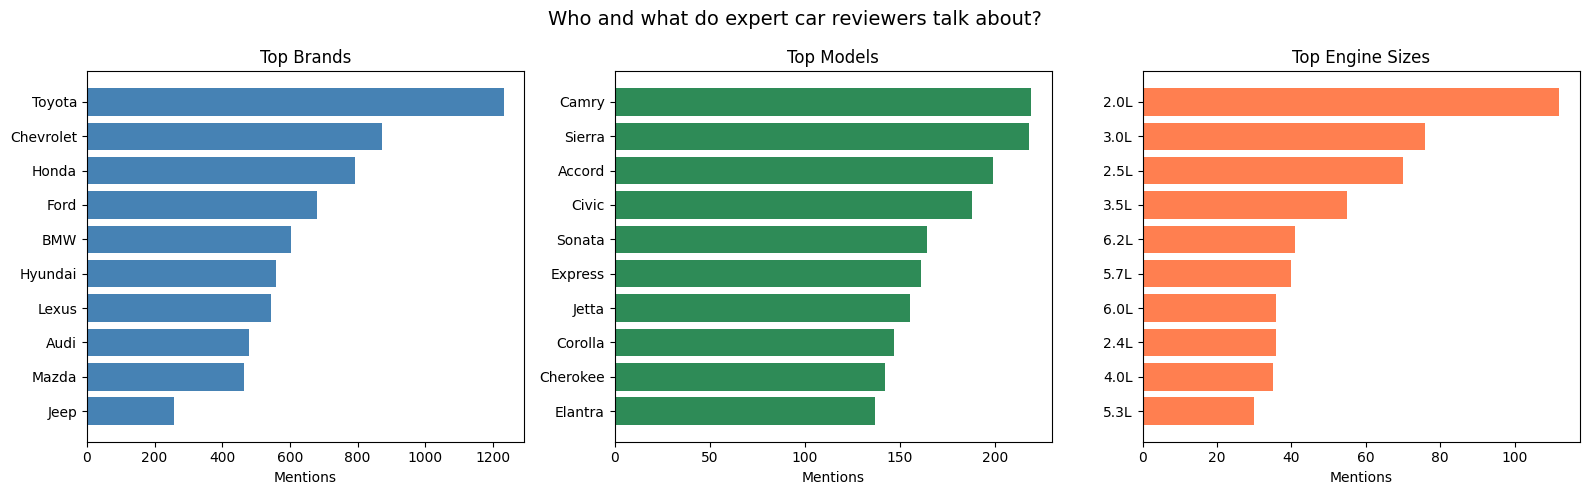

In [28]:
# Playground: cleaned top entities + 3-panel chart
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

def merge_counts(*counters, alias=None, strip_brand=False):
    """Merge case/alias/brand-prefix variants; display the most common spelling."""
    totals, spellings = Counter(), defaultdict(Counter)
    for c in counters:
        for text, n in c.items():
            key = norm(text)
            if alias:
                key = alias.get(key, key)
            if strip_brand:
                for b in sorted(brand_set, key=len, reverse=True):
                    if key.startswith(b + " "):
                        key = key[len(b) + 1:]
                        break
            totals[key] += n
            spellings[key][text] += n
    return [(spellings[k].most_common(1)[0][0], n) for k, n in totals.most_common()]

brand_counts = merge_counts(org_class["brand"], alias={"chevy": "chevrolet", "vw": "volkswagen"})[:10]
model_counts = merge_counts(org_class["model"], prod_class["model"], strip_brand=True)[:10]

# Engine sizes: normalize '2.0-liter' / '2.0 liter' / '2.0L' -> '2.0L'
engine_sizes = Counter()
for q in my_entities["QUANTITY"]:
    if quantity_type(q) == "engine size (liters)":
        m = re.search(r"(\d\.\d)", q)
        if m:
            engine_sizes[f"{m.group(1)}L"] += 1
engine_counts = engine_sizes.most_common(10)

for title, counts in [("TOP 10 BRANDS", brand_counts),
                      ("TOP 10 MODELS", model_counts),
                      ("TOP 10 ENGINE SIZES", engine_counts)]:
    print(f"\n📊 {title}")
    print("-" * 40)
    for name, count in counts:
        print(f"   {name:30} {count:4}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
panels = [("Top Brands", brand_counts, "steelblue"),
          ("Top Models", model_counts, "seagreen"),
          ("Top Engine Sizes", engine_counts, "coral")]

for ax, (title, counts, color) in zip(axes, panels):
    if counts:
        names, values = zip(*counts)
        ax.barh(names, values, color=color)
        ax.invert_yaxis()                      # most frequent on top
    ax.set_title(title)
    ax.set_xlabel("Mentions")

fig.suptitle("Who and what do expert car reviewers talk about?", fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
# Playground step 3: hunt the misses
from spacy import displacy
import random

# trying seeding with 8 to get some more variety
random.seed(8)
candidates = random.sample(range(len(my_texts)), 200)
snippets = [my_texts[i][:600] for i in candidates]
docs = list(nlp.pipe(snippets, batch_size=32))

# take the 4 most entity-dense snippets
top = sorted(range(len(docs)), key=lambda k: len(docs[k].ents), reverse=True)[:4]

for n, k in enumerate(top, 1):
    doc = docs[k]

    print("=" * 80)
    print(f"Review {n} (index {candidates[k]}) — {len(doc.ents)} entities")
    print("=" * 80)

    displacy.render(doc, style="ent", jupyter=True)

    print(f"\n{'ENTITY':28}{'LABEL':10}FLAG")
    print("-" * 60)

    for ent in doc.ents:
        kind = classify_name(ent.text)
        flag = ""
        if kind == "model" and ent.label_ != "PRODUCT":
            flag = "⚠ model not tagged PRODUCT"
        elif kind == "brand" and ent.label_ != "ORG":
            flag = "⚠ brand not tagged ORG"

        print(f"{ent.text:28}{ent.label_:10}{flag}")
    print()

Review 1 (index 1999) — 19 entities



ENTITY                      LABEL     FLAG
------------------------------------------------------------
2016                        DATE      
BMW M2                      ORG       ⚠ model not tagged PRODUCT
2                           CARDINAL  
Series                      EVENT     
2016                        DATE      
BMW M2                      ORG       ⚠ model not tagged PRODUCT
M3                          PRODUCT   
M4                          PRODUCT   
2011                        DATE      
BMW                         ORG       
M Division                  ORG       
1 M Coupe                   PRODUCT   
1                           CARDINAL  
Series                      EVENT     
one                         CARDINAL  
Fewer than 1,000            CARDINAL  
the United States           GPE       
2014                        DATE      
BMW                         ORG       

Review 2 (index 2716) — 18 entities



ENTITY                      LABEL     FLAG
------------------------------------------------------------
2021                        DATE      
Mazda                       ORG       
3                           PRODUCT   
this year                   DATE      
Mazda                       ORG       
four                        CARDINAL  
Mazda                       ORG       
CX-5                        PRODUCT   
CX-9                        ORG       ⚠ model not tagged PRODUCT
227                         CARDINAL  
310 lb-ft                   QUANTITY  
250                         CARDINAL  
320 lb-ft                   QUANTITY  
93                          CARDINAL  
Mazda                       ORG       
3                           CARDINAL  ⚠ model not tagged PRODUCT
2013                        DATE      
3                           CARDINAL  ⚠ model not tagged PRODUCT

Review 3 (index 1457) — 17 entities



ENTITY                      LABEL     FLAG
------------------------------------------------------------
2006                        DATE      
two                         CARDINAL  
Ford                        ORG       
first                       ORDINAL   
Tungsten Grey               PERSON    
1966                        DATE      
second                      ORDINAL   
the JW Automotive/American Gulf Oil-sponsoredORG       
Le Mans                     ORG       
1968                        DATE      
1969                        DATE      
21st-century                DATE      
American                    NORP      
2006                        DATE      
Ford                        ORG       
Ford                        ORG       
al                          PERSON    

Review 4 (index 135) — 17 entities



ENTITY                      LABEL     FLAG
------------------------------------------------------------
five                        CARDINAL  
1996                        DATE      
Blazer                      PRODUCT   
five                        CARDINAL  
two                         CARDINAL  
More than a decade          DATE      
1982                        DATE      
the S-10 Blazer             PRODUCT   
General Motors              ORG       
1995                        DATE      
S-10                        PRODUCT   
S-10                        PRODUCT   
1995                        DATE      
Blazer                      PRODUCT   
4.3L V6                     QUANTITY  
Blazer                      PRODUCT   
two                         CARDINAL  



In [30]:
# Playground step 3: hunt the misses
from spacy import displacy
import random

random.seed(7)
candidates = random.sample(range(len(my_texts)), 200)
snippets = [my_texts[i][:600] for i in candidates]
docs = list(nlp.pipe(snippets, batch_size=32))

# take the 4 most entity-dense snippets
top = sorted(range(len(docs)), key=lambda k: len(docs[k].ents), reverse=True)[:4]

for n, k in enumerate(top, 1):
    doc = docs[k]

    print("=" * 80)
    print(f"Review {n} (index {candidates[k]}) — {len(doc.ents)} entities")
    print("=" * 80)

    displacy.render(doc, style="ent", jupyter=True)

    print(f"\n{'ENTITY':28}{'LABEL':10}FLAG")
    print("-" * 60)

    for ent in doc.ents:
        kind = classify_name(ent.text)
        flag = ""
        if kind == "model" and ent.label_ != "PRODUCT":
            flag = "⚠ model not tagged PRODUCT"
        elif kind == "brand" and ent.label_ != "ORG":
            flag = "⚠ brand not tagged ORG"

        print(f"{ent.text:28}{ent.label_:10}{flag}")
    print()

Review 1 (index 622) — 18 entities



ENTITY                      LABEL     FLAG
------------------------------------------------------------
Lexus                       ORG       
300                         CARDINAL  ⚠ model not tagged PRODUCT
Toyota                      ORG       
Highlander                  ORG       ⚠ model not tagged PRODUCT
today                       DATE      
V6                          GPE       
Highlander                  ORG       ⚠ model not tagged PRODUCT
one                         CARDINAL  
Limited                     ORG       
Camry                       PRODUCT   
REI                         ORG       
one                         CARDINAL  
10                          CARDINAL  
U.S.                        GPE       
Lexus                       ORG       
Toyota                      ORG       
Highlander                  ORG       ⚠ model not tagged PRODUCT
Toyota                      ORG       

Review 2 (index 529) — 17 entities



ENTITY                      LABEL     FLAG
------------------------------------------------------------
four                        CARDINAL  
100,000-mile                QUANTITY  
V6                          GPE       
four                        CARDINAL  
2000                        DATE      
Honda                       ORG       
Accord                      PRODUCT   
this year                   DATE      
Nighthawk Black             PERSON    
Starlight Black             PERSON    
Naples Gold Metallic        PERSON    
Heather Mist Metallic       PERSON    
Raisin                      PERSON    
Accord                      PRODUCT   
one                         CARDINAL  
America                     GPE       
America                     GPE       

Review 3 (index 257) — 16 entities



ENTITY                      LABEL     FLAG
------------------------------------------------------------
Honda                       ORG       
1998                        DATE      
3.0-liter                   QUANTITY  
V6                          GPE       
LX V6                       GPE       
first                       ORDINAL   
six                         CARDINAL  
Honda                       ORG       
2.3-liter                   QUANTITY  
four                        CARDINAL  
1998                        DATE      
Honda                       ORG       
Accord                      PRODUCT   
America                     GPE       
Accord                      PRODUCT   
Accord                      PRODUCT   

Review 4 (index 2027) — 16 entities



ENTITY                      LABEL     FLAG
------------------------------------------------------------
last model year             DATE      
2012                        DATE      
Volkswagen                  ORG       
Jetta                       PRODUCT   
SEL                         NORP      
TDI                         ORG       
Fender                      ORG       
last year's                 DATE      
SEL                         ORG       
2012                        DATE      
Volkswagen                  ORG       
Jetta                       PRODUCT   
Volkswagen                  ORG       
Jetta                       PRODUCT   
Japanese                    NORP      
German                      NORP      



### 🔍 Hunting the misses (Playground step 3)

I ran spaCy on two batches of four entity-dense car reviews (8 reviews total) and read the tags as a domain insider. The model handled brands and years well, but it has no label for car models, trims, engines, or paint colors, so those get forced into labels meant for other things.

**Missed entirely (no tag at all)**

| Missed | Where | Why it matters |
|---|---|---|
| RX (in "Lexus RX 300") | Batch 1 | Only "300" was tagged, as a CARDINAL, so the model name was split in two |
| VTEC | Batch 1 | Honda's engine technology |
| EX, SE, EX V6 | Batch 1 | Trim levels |
| Currant | Batch 1 | Paint color, right next to "Raisin", which *was* tagged |
| GT40, "GT" in "Ford GT" | Batch 2 | The central car in the passage; only "Ford" was tagged |
| Mazdaspeed 3, Heritage Edition | Batch 2 | A model variant and a trim/package |
| "227 hp", "250 hp", "93 octane" | Batch 2 | Only the bare numbers were tagged as CARDINAL, so the units were lost |

**Mislabeled (real entity, wrong label)**

| Entity | Tagged as | Should be |
|---|---|---|
| Highlander (×3) | ORG | PRODUCT (Camry and Accord in the same reviews were correctly PRODUCT) |
| BMW M2 (×2) | ORG | PRODUCT; brand and model were fused into one span |
| CX-9 | ORG | PRODUCT (CX-5 in the same sentence was tagged correctly) |
| Mazda "3" | PRODUCT once, CARDINAL twice | PRODUCT; one model got two different labels in one review |
| SEL | NORP once, ORG once | Trim level; the two tags in one review disagree with each other |
| TDI, Limited | ORG | Engine designation and trim level |
| "2 Series" / "1 Series" | CARDINAL + EVENT | PRODUCT; one name was split into two wrong tags |
| Le Mans | ORG | Race/place (debatable) |
| "the JW Automotive/American Gulf Oil-sponsored" | ORG | A boundary error: the span swallowed "the" and "sponsored" and merged two companies |

**Hallucinated (tagged as something it isn't)**

- **V6 → GPE** (four times, including "LX V6"). It is an engine configuration, not a place.
- **Paint colors → PERSON**: Nighthawk Black, Starlight Black, Naples Gold Metallic, Heather Mist Metallic, Raisin, Tungsten Grey.
- **Series → EVENT**, from the split "1 Series" / "2 Series" names above.

*Note: one PERSON tag ("al") was a word fragment caused by my 600-character snippet cutoff, not a model error, so I excluded it.*

**What spaCy got right:** brands (Toyota, Honda, Ford, Volkswagen, BMW, General Motors), real companies outside the car industry (REI, Fender), nationalities (Japanese, German, American), model years, and many models (Camry, Accord, Jetta, M3, M4, CX-5, Blazer, S-10).

**Pattern:** the errors are *inconsistent*, not random. The same kind of name (Highlander vs. Camry, CX-9 vs. CX-5) gets different labels within a single review. Models whose names are numbers ("Mazda 3", "1 Series") fail most often. These counts come from only 8 hand-picked, entity-dense reviews, so they illustrate the failure types and shouldn't be read as an overall error rate.

### Questions

Q1: Were the extracted entities accurate? What errors did you observe?

A1. Partially, brands, nationalities, and years were correct but anything else was not. Org did get a 47% match so I believe with further refinement and exploration of the dataset a higher match could have been achieved. Bugs like the car models being labelled as brands, different spellings and abbreviations of brands, and non brand like android, apple play, EPA are orgs but not car brands so this could have been caught or handled better to help get better match rates. It is correct some of these other values are orgs just not car orgs.These values got bucketed as other and amounted to about 25% of the mismatch.


Q2: What business insights can you derive from entity mentions?

A2. A major insight that could be gleamed and put in a deck would be how enitity counts showed which brands, models, and specs got the most reviews. A business could track the mention of a particular product and compare that to its competitor and do sentiment analysis to determine which product is seen a more favorable and measure its reception. This measurment can than be compared to sales to help with inventory and manufacturing planning. Quantitiy mentions what is discussed in the reviews. So this might help the business to know what features are popular and what was unpopular. The business would still have to be mindful of bias of course as no every trim of a model is reviwed so there can be slated views of a given product especially if the reviewer is the one picking the model or if the business is trying to push a certain product model/trim.


Q3: How could you improve NER for your specific domain?

A3. A major issue is the spacy library limitation in labeling and how things get parsed. Hyphens are not fun to deal with. Depending on the dataset how a value is spelled or the number of ways it can be spelled cause issues like abbreviations. This lack of consist convention requires through deep diving and hunting for edge cases to help the library do what it is designed to do. Alias as mentioned and model names as numbers were difficult to deal with. Cars are notorious for using numbers for models, Ferrari for instance is known to do this, but other manufacures do this inconsistently. For exmaple the one I found was the MazdaSpeed3 and the Ford GT40. What should have been done is a pre cleaning of the reviews before training on a smaller sample size. i used nearly 20% which was about 600 reviews. I also would have used a list or dictionary to reference from as a check. So different alias would have been easier to catch I think.


Q4: What patterns did you observe in the entity distributions?

A4. I noticed brands names are mentioneds as top heavy so the first branad, Toyota is menitioned about 5x as much as the tenth brand, Jeep. Models do not have that kind of spread and are more bunched together. Also with Models being much more than brands in terms of unique values it makes sense the spread is tighter compare dto brands which is a smaller unique value set.

Another trend I noticed is the model years are spread fairly evenly. This spread could be a bias though since it was so even.

A final trend I noticed was engine size displacement. Smaller engines together and bigger engines in their own grouping.

## 🤔 Debrief

1. You pitch "NER-powered competitor monitoring" to a brand team. Based on the errors
   you saw today, what accuracy caveats go on the slide — and which downstream decisions
   should NEVER be fully automated on top of this output?
2. When is a rules/dictionary approach (a fixed list of competitor names) *better* than
   a statistical NER model? When does the dictionary approach fall apart?


## 📤 Submit (HW5 — 40 points)

**Deliverables (submit through Canvas):**
- Completed `.ipynb` executed top-to-bottom, INCLUDING the Playground run on your own domain's text (both 3-panel charts visible, misses documented)

**Answer these questions in a markdown cell at the end of your notebook:**
- **Q1:** Were the extracted entities accurate? What errors did you observe?
- **Q2:** What business insights can you derive from entity mentions?
- **Q3:** How could you improve NER for your specific domain?
- **Q4:** What patterns did you observe in the entity distributions?

**Grading:**

| Part | Points |
|---|---|
| Part 1: Setup and Data | 6 |
| Part 2: NER Demo | 8 |
| Part 3: Entity Extraction | 12 |
| Part 4: Analyze Patterns | 8 |
| Part 5: Visualization | 6 |

**Due Sunday 10:00 p.m.** — see the Canvas assignment for the exact date. Late work is not accepted (see syllabus).

*AI policy: AI tools are allowed and encouraged. Add one line acknowledging what you used, and be ready to explain every part of what you submit.*
